# Delhi Air Quality Analysis

## ShadowFox Data Science Internship

**Name:** Ananya Mandal

This project analyzes Delhi's air pollution data using Python. It explores different pollutants, identifies trends, and presents insights through statistical analysis and data visualization.

## Introduction

Air pollution is one of the major environmental challenges in Delhi. Pollutants released from vehicles, industries, and construction activities affect air quality and public health. Monitoring these pollutants helps us understand pollution patterns and supports better environmental planning.

In this project, different pollutants such as PM2.5, PM10, CO, NO, NO₂, SO₂, O₃, and NH₃ are analyzed using Python, along with visualizations to identify trends and relationships.

## Objective

The objective of this project is to analyze Delhi's air pollution data, understand pollutant levels, identify trends over time, and visualize relationships between different pollutants using Python.

## Research Questions

1. Which pollutant has the highest concentration?
2. How do pollutant levels change over time?
3. What is the distribution of PM2.5 and PM10?
4. Is there any relationship between different pollutants?
5. Which pollutants contribute most to poor air quality?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving delhiaqi.csv to delhiaqi.csv


In [3]:
df = pd.read_csv("delhiaqi.csv")

In [4]:
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non-null    float64
 3   no2     561 non-null    float64
 4   o3      561 non-null    float64
 5   so2     561 non-null    float64
 6   pm2_5   561 non-null    float64
 7   pm10    561 non-null    float64
 8   nh3     561 non-null    float64
dtypes: float64(8), object(1)
memory usage: 39.6+ KB


In [6]:
df.shape

(561, 9)

In [7]:
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
std,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094
min,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000


In [8]:
df.isnull().sum()

,0
date,0
co,0
no,0
no2,0
o3,0
so2,0
pm2_5,0
pm10,0
nh3,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df["date"] = pd.to_datetime(df["date"])

In [12]:
df.dtypes

,0
date,datetime64[ns]
co,float64
no,float64
no2,float64
o3,float64
so2,float64
pm2_5,float64
pm10,float64
nh3,float64


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset before performing detailed analysis. It allows us to identify patterns, trends, and relationships between different pollutants using summary statistics and visualizations.

In [13]:
df.head(10)

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19
5,2023-01-01 05:00:00,3578.19,64.37,55.52,14.13,44.35,276.54,336.79,16.21
6,2023-01-01 06:00:00,3578.19,46.94,76.09,33.26,50.54,295.40,357.07,19.25
7,2023-01-01 07:00:00,1468.66,9.83,47.30,105.86,68.66,158.83,182.61,7.09
8,2023-01-01 08:00:00,1161.58,5.81,35.99,125.89,61.99,134.39,153.47,5.51
9,2023-01-01 09:00:00,1161.58,4.58,36.33,134.47,65.80,133.22,152.09,6.02


In [14]:
df.columns

Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')

In [15]:
print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

Start Date: 2023-01-01 00:00:00
End Date: 2023-01-24 08:00:00


### Observation

The dataset contains air pollution records collected between the above dates. This helps us understand the time period covered in the analysis.

## 1. PM2.5 Trend Over Time

PM2.5 consists of very fine particles that can enter the lungs and bloodstream. Monitoring its trend helps us understand changes in air pollution over time.

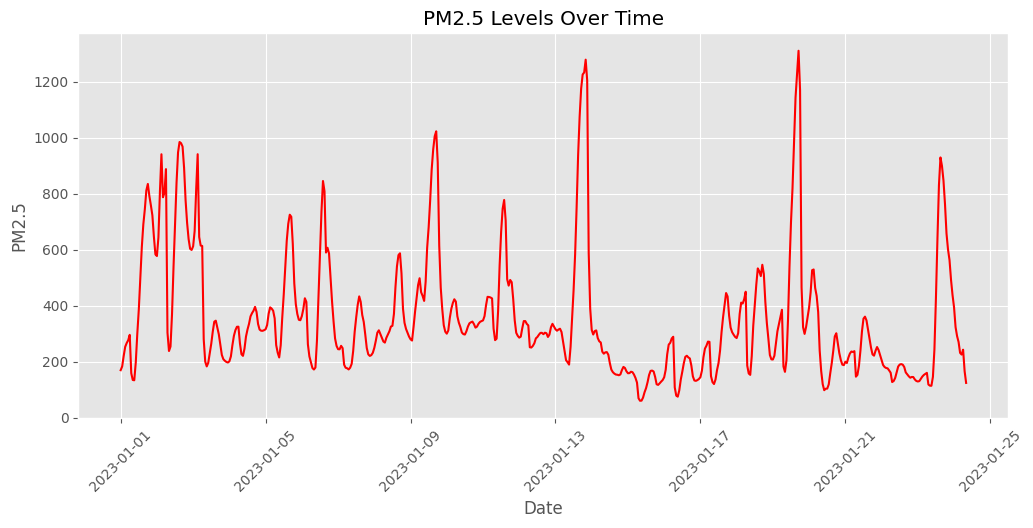

In [16]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["pm2_5"], color="red")

plt.title("PM2.5 Levels Over Time")

plt.xlabel("Date")

plt.ylabel("PM2.5")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Observation

The graph shows how PM2.5 levels change over time. Higher peaks indicate periods of increased air pollution, while lower values represent comparatively cleaner air.

## 2. PM10 Trend Over Time

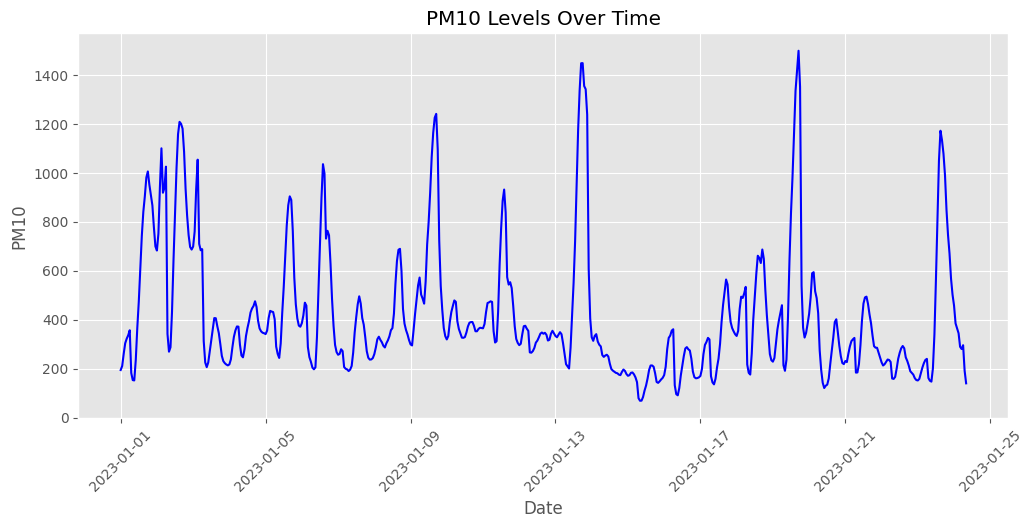

In [17]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["pm10"], color="blue")

plt.title("PM10 Levels Over Time")

plt.xlabel("Date")

plt.ylabel("PM10")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Observation

The PM10 levels fluctuate over time, showing that air quality varies throughout the observed period.

## 3. Distribution of PM2.5

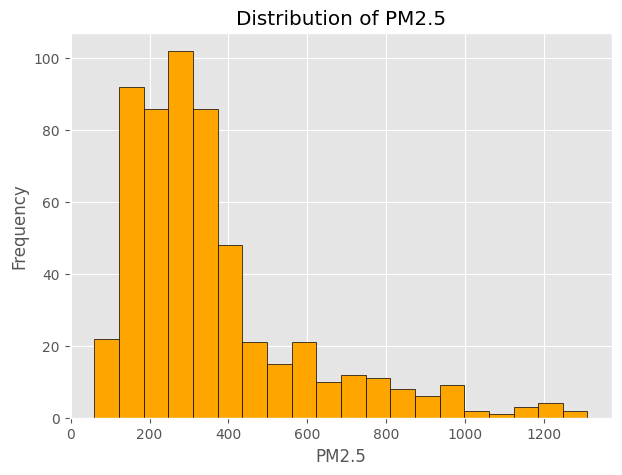

In [18]:
plt.figure(figsize=(7,5))

plt.hist(df["pm2_5"], bins=20, color="orange", edgecolor="black")

plt.title("Distribution of PM2.5")

plt.xlabel("PM2.5")

plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows how frequently different PM2.5 values occur. Most observations are concentrated within a particular range, while a few higher values indicate severe pollution events.

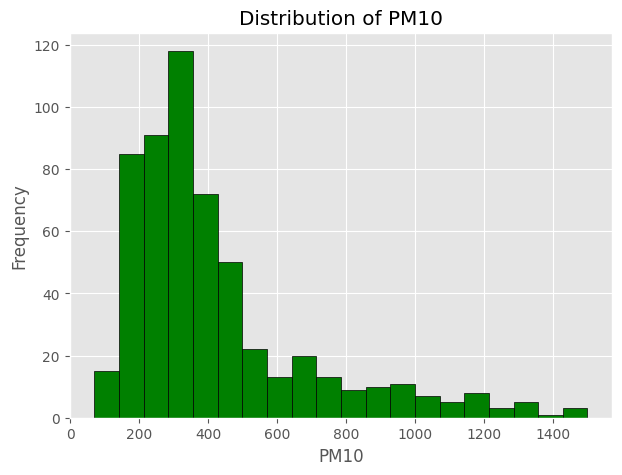

In [19]:
plt.figure(figsize=(7,5))

plt.hist(df["pm10"], bins=20, color="green", edgecolor="black")

plt.title("Distribution of PM10")

plt.xlabel("PM10")

plt.ylabel("Frequency")

plt.show()

## 4. Box Plot of PM2.5

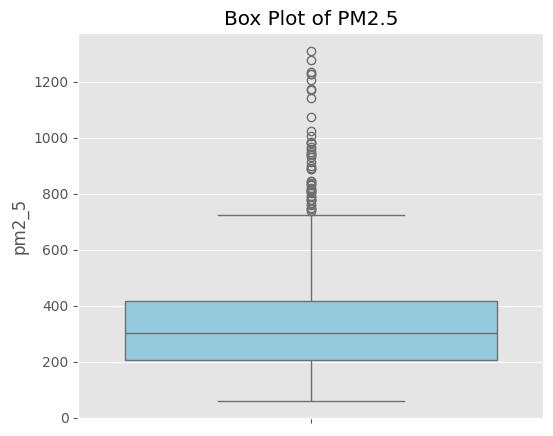

In [20]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["pm2_5"], color="skyblue")

plt.title("Box Plot of PM2.5")

plt.show()

### Observation

The box plot highlights the spread of PM2.5 values and identifies potential outliers, which represent unusually high pollution levels.

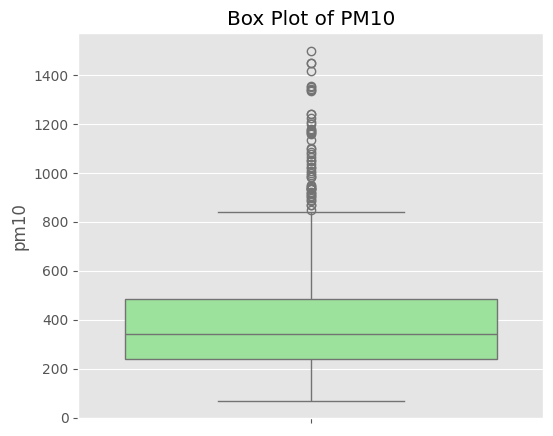

In [21]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["pm10"], color="lightgreen")

plt.title("Box Plot of PM10")

plt.show()

## 5. Correlation Between Pollutants

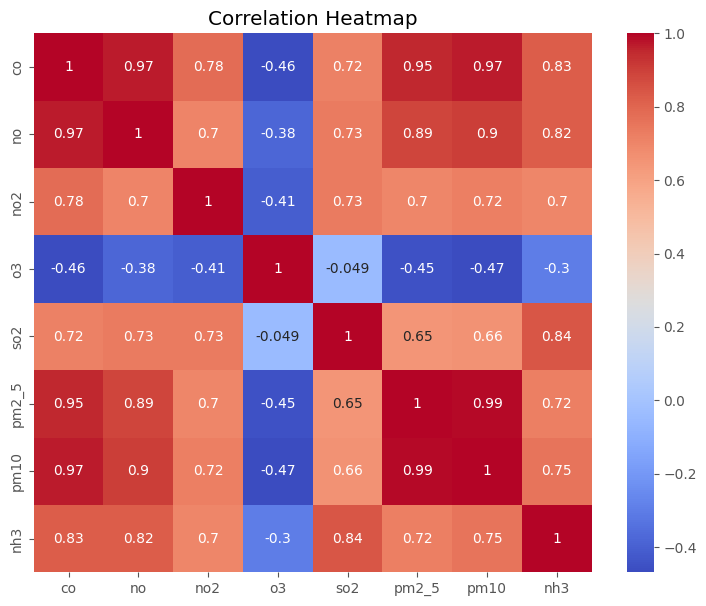

In [22]:
plt.figure(figsize=(9,7))

corr = df.drop(columns=["date"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the correlation between pollutants. Positive values indicate that two pollutants tend to increase together, while negative values suggest an inverse relationship.

## 6. Relationship Between PM2.5 and PM10

A scatter plot helps us understand whether PM2.5 and PM10 are related. If the points form an upward trend, it indicates that both pollutants tend to increase together.

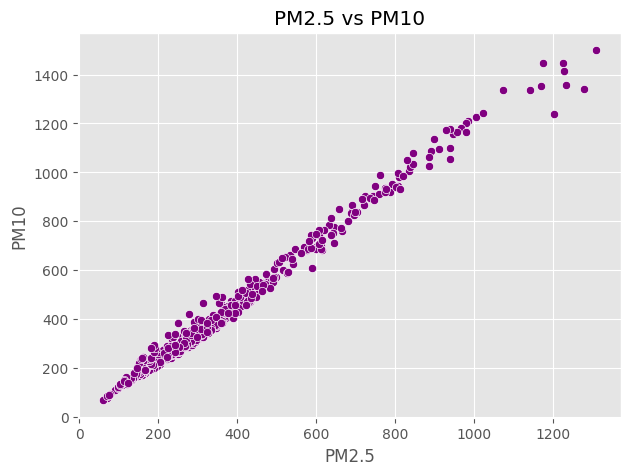

In [23]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="pm2_5",
    y="pm10",
    color="purple"
)

plt.title("PM2.5 vs PM10")

plt.xlabel("PM2.5")

plt.ylabel("PM10")

plt.show()

### Observation

The scatter plot shows a positive relationship between PM2.5 and PM10. Higher PM2.5 values are generally associated with higher PM10 values.

## 7. Average Concentration of Pollutants

This chart compares the average concentration of each pollutant in the dataset.

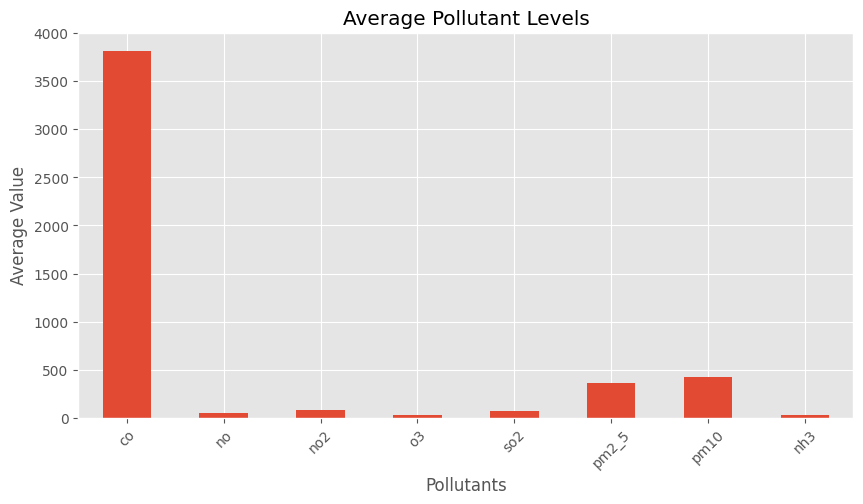

In [24]:
average_pollutants = df.drop(columns=["date"]).mean()

plt.figure(figsize=(10,5))

average_pollutants.plot(kind="bar")

plt.title("Average Pollutant Levels")

plt.xlabel("Pollutants")

plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.show()

### Observation

The bar chart shows the average concentration of each pollutant. It helps identify which pollutants are present at relatively higher levels.

## Statistical Analysis

Basic statistical measures provide a quick summary of the dataset and help us understand pollutant concentrations.

In [25]:
df.describe()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,2023-01-12 16:00:00,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
min,2023-01-01 00:00:00,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,2023-01-06 20:00:00,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2023-01-12 16:00:00,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,2023-01-18 12:00:00,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,2023-01-24 08:00:00,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000
std,NaN,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094


In [26]:
df.mean(numeric_only=True)

,0
co,3814.942210
no,51.181979
no2,75.292496
o3,30.141943
so2,64.655936
pm2_5,358.256364
pm10,420.988414
nh3,26.425062


In [27]:
df.median(numeric_only=True)

,0
co,2590.18
no,13.30
no2,63.75
o3,11.80
so2,47.21
pm2_5,301.17
pm10,340.90
nh3,14.82


In [28]:
df.std(numeric_only=True)

,0
co,3227.744681
no,83.904476
no2,42.473791
o3,39.979405
so2,61.073080
pm2_5,227.359117
pm10,271.287026
nh3,36.563094


In [29]:
df.max(numeric_only=True)

,0
co,16876.22
no,425.58
no2,263.21
o3,164.51
so2,511.17
pm2_5,1310.20
pm10,1499.27
nh3,267.51


In [30]:
df.min(numeric_only=True)

,0
co,654.22
no,0.00
no2,13.37
o3,0.00
so2,5.25
pm2_5,60.10
pm10,69.08
nh3,0.63


## Key Findings

- PM2.5 and PM10 were among the most significant pollutants in the dataset.
- Pollutant concentrations varied over time, indicating changing air quality conditions.
- The correlation heatmap showed positive relationships between several pollutants.
- The scatter plot suggested that PM2.5 and PM10 tend to increase together.
- Distribution plots and box plots highlighted the presence of variability and some extreme pollution values.

## Conclusion

This analysis provided an overview of Delhi's air pollution using data visualization and statistical techniques. The results showed noticeable variations in pollutant concentrations and relationships between different pollutants. These insights can support better understanding of air quality trends and emphasize the importance of continuous environmental monitoring and pollution control measures.

## References

1. ShadowFox Internship Dataset
2. Pandas Documentation – https://pandas.pydata.org/
3. Matplotlib Documentation – https://matplotlib.org/
4. Seaborn Documentation – https://seaborn.pydata.org/